# CCMA multi-omic coverage map

Visualises per-cell-line coverage of each CCMA omic layer and how many cell lines could be augmented to the union total. Reads the processed CSVs in `data/clines/ccma_processed/` written by `preprocess_CCMA.ipynb`.

Toggle `INCLUDE_CRISPR` in cell 2 to drop the CRISPR-Cas12 row (used when the downstream model is trained on the no-CRISPR omic stack).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

PROJECT_ROOT = Path('/home/scai/scratch/PhenPredCCMA/')
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
from _plot_style import PALETTE, configure_nature_style, save_figure

OUT_DIR = PROJECT_ROOT / 'data' / 'clines' / 'ccma_processed'
FIG_DIR = PROJECT_ROOT / 'reports' / 'vae'

configure_nature_style('full')

In [2]:
# ── Toggle ─────────────────────────────────────────────────────────────
INCLUDE_CRISPR = False

omic_files = {
    'Transcriptomics': (OUT_DIR / 'transcriptomics_ccma.csv',  'feat_x_samp'),
    'CRISPR-Cas12':    (OUT_DIR / 'crisprcas9_ccma.csv',       'samp_x_feat'),
    'Drug response':   (OUT_DIR / 'drugresponse_ccma.csv',     'feat_x_samp'),
    'Methylation':     (OUT_DIR / 'methylation_ccma.csv',      'feat_x_samp'),
    'Copy number':     (OUT_DIR / 'copynumber_ccma.csv',       'samp_x_feat'),
    'Mutations (SNV)': (OUT_DIR / 'mutations_binary_ccma.csv', 'feat_x_samp'),
}
if not INCLUDE_CRISPR:
    omic_files.pop('CRISPR-Cas12', None)

omic_sample_ids = {}
for omic, (path, layout) in omic_files.items():
    if not path.exists():
        print(f'Skipping {omic}: file not found at {path}')
        continue
    if layout == 'feat_x_samp':
        df_head = pd.read_csv(path, index_col=0, nrows=0)
        omic_sample_ids[omic] = set(df_head.columns)
    else:
        df_idx = pd.read_csv(path, index_col=0, usecols=[0])
        omic_sample_ids[omic] = set(df_idx.index)

if not omic_sample_ids:
    raise ValueError('No omic files were available for plotting.')

all_samples = sorted(set.union(*omic_sample_ids.values()))
N_total = len(all_samples)
sample_idx = {s: i for i, s in enumerate(all_samples)}

print(f'Total unique cell lines (union): {N_total:,}')
for omic, ids in omic_sample_ids.items():
    print(f'  {omic:<18s} measured={len(ids):>5,d}   augmentable=+{N_total - len(ids):>5,d}')

Total unique cell lines (union): 437
  Transcriptomics    measured=  385   augmentable=+   52
  Drug response      measured=  268   augmentable=+  169
  Methylation        measured=  353   augmentable=+   84
  Copy number        measured=  322   augmentable=+  115
  Mutations (SNV)    measured=  313   augmentable=+  124


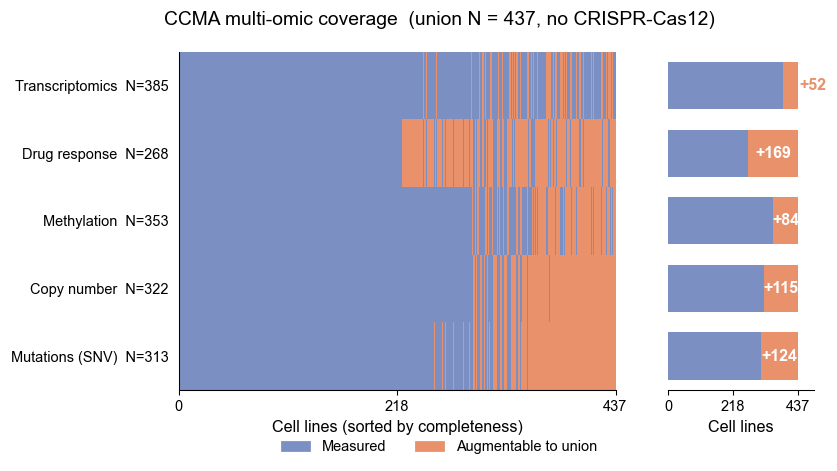

Saved: /home/scai/scratch/PhenPredCCMA/reports/vae/ccma_multiomic_map_no_crispr.png and /home/scai/scratch/PhenPredCCMA/reports/vae/ccma_multiomic_map_no_crispr.pdf


In [3]:
# ── Build presence matrix and sort samples by completeness ─────────────
omic_names = list(omic_sample_ids.keys())
n_omics = len(omic_names)

presence = np.zeros((n_omics, N_total), dtype=np.int8)
for i, omic in enumerate(omic_names):
    for sid in omic_sample_ids[omic]:
        presence[i, sample_idx[sid]] = 1

completeness = presence.sum(axis=0)
sort_order = np.lexsort((np.array(all_samples), -completeness))
presence_sorted = presence[:, sort_order]

n_measured = presence.sum(axis=1)
n_augment = N_total - n_measured
omic_labels = [f'{o}  N={n:,}' for o, n in zip(omic_names, n_measured)]

# Original palette from preprocess_CCMA.ipynb — soft periwinkle + warm peach.
# See the palette-comparison cell below for alternative pairs (NPG, Cell-muted,
# teal+pink, sage+plum, etc.) — swap two lines if you ever want to try one.
CLR_MEASURED = '#7B8FC2'   # soft periwinkle — focus
CLR_AUGMENT  = '#E8916A'   # warm peach — contrast

# ── Figure ─────────────────────────────────────────────────────────────
fig_h = 0.55 * n_omics + 1.4
fig = plt.figure(figsize=(7.4, fig_h))

gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.18)
ax_rug = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1])

# Rug: row i = omic_names[i]; columns are samples sorted by completeness.
cmap = mcolors.ListedColormap([CLR_AUGMENT, CLR_MEASURED])
norm = mcolors.BoundaryNorm([0, 0.5, 1], cmap.N)
ax_rug.imshow(
    presence_sorted,
    aspect='auto',
    cmap=cmap,
    norm=norm,
    extent=[0, N_total, n_omics - 0.5, -0.5],
    interpolation='nearest',
)
ax_rug.set_yticks(np.arange(n_omics))
ax_rug.set_yticklabels(omic_labels)
ax_rug.set_xticks([0, N_total // 2, N_total])
ax_rug.set_xlabel('Cell lines (sorted by completeness)')
ax_rug.spines[['top', 'right']].set_visible(False)
ax_rug.tick_params(left=False)

# Right: stacked bar — measured then augmentable.
bar_h = 0.7
INSIDE_LABEL_MIN = 0.18 * N_total   # narrower segments get their label outside the bar
bar_xmax = N_total * 1.12           # headroom for outside labels

for i in range(n_omics):
    ax_bar.barh(i, n_measured[i], height=bar_h, color=CLR_MEASURED, edgecolor='none', left=0)
    ax_bar.barh(i, n_augment[i],  height=bar_h, color=CLR_AUGMENT,  edgecolor='none', left=n_measured[i])
    if n_augment[i] > 0:
        if n_augment[i] >= INSIDE_LABEL_MIN:
            ax_bar.text(
                n_measured[i] + n_augment[i] / 2, i,
                f'+{int(n_augment[i]):,}',
                ha='center', va='center',
                color='white', fontweight='bold',
            )
        else:
            ax_bar.text(
                n_measured[i] + n_augment[i] + N_total * 0.012, i,
                f'+{int(n_augment[i]):,}',
                ha='left', va='center',
                color=CLR_AUGMENT, fontweight='bold',
            )

ax_bar.set_xlim(0, bar_xmax)
ax_bar.set_ylim(n_omics - 0.5, -0.5)
ax_bar.set_yticks([])
ax_bar.set_xticks([0, N_total // 2, N_total])
ax_bar.set_xlabel('Cell lines')
ax_bar.spines[['top', 'right', 'left']].set_visible(False)

crispr_tag = 'with CRISPR-Cas12' if INCLUDE_CRISPR else 'no CRISPR-Cas12'
fig.suptitle(f'CCMA multi-omic coverage  (union N = {N_total:,}, {crispr_tag})', y=0.99)

fig.legend(
    handles=[
        mpatches.Patch(color=CLR_MEASURED, label='Measured'),
        mpatches.Patch(color=CLR_AUGMENT,  label='Augmentable to union'),
    ],
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.01),
)

fig.subplots_adjust(left=0.18, right=0.96, top=0.90, bottom=0.16)

suffix = 'with_crispr' if INCLUDE_CRISPR else 'no_crispr'
out_path = FIG_DIR / f'ccma_multiomic_map_{suffix}'
save_figure(fig, out_path, close=False)
plt.show()
print(f'Saved: {out_path}.png and {out_path}.pdf')